# Exploratory Data Analysis

## Plotting

Let's plot some stuff!

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from ipywidgets import interact, FloatSlider, IntSlider
rng = np.random.default_rng(42)

from astroML.datasets import fetch_sdss_galaxy_colors


Let's load some data:

In [8]:
from astroML.datasets import fetch_sdss_S82standards
data = fetch_sdss_S82standards(crossmatch_2mass=True)

downloading cross-matched SDSS/2MASS dataset from https://github.com/astroML/astroML-data/raw/main/datasets/stripe82calibStars_2MASS_v2.6.dat.gz to /Users/danielahuppenkothen/astroML_data
[=========================================]  25.57Mb / 25.57Mb   
uncompressing file...


In [9]:
data

array([(3.43400000e-03, -0.077309 , 0.046, 0.045, 13, 0.092,  0, -0.193, -0.193, 0.   , 0.   , 0. , 12, 21.382, 21.367, 0.015, 0.078, 1.8, 12, 19.896, 19.898, 0.007, 0.021, 0.6, 12, 18.492, 18.494, 0.006, 0.027, 1.4, 12, 17.749, 17.74 , 0.008, 0.042, 2.6, 3.4749999e-03, -0.077231, 16.252, 0.094, 15.763, 0.151, 15.655, 0.255, 0.32),
       (1.73090000e-02, -0.033012 , 0.03 , 0.057, 13, 0.091, 12, 20.501, 20.505, 0.019, 0.094, 1.6, 12, 18.299, 18.302, 0.006, 0.021, 0.7, 12, 17.314, 17.31 , 0.005, 0.01 , 0.3, 12, 16.93 , 16.922, 0.005, 0.024, 2.1, 12, 16.704, 16.708, 0.006, 0.017, 0.5, 1.7379999e-02, -0.032945, 15.591, 0.059, 15.023, 0.073, 15.069, 0.154, 0.35),
       (1.94840000e-02, -0.056911 , 0.029, 0.03 , 13, 0.092, 12, 18.999, 18.999, 0.008, 0.028, 1. , 12, 17.803, 17.801, 0.006, 0.02 , 0.7, 12, 17.296, 17.288, 0.005, 0.016, 0.9, 12, 17.064, 17.067, 0.005, 0.021, 1.3, 12, 16.95 , 16.944, 0.007, 0.033, 1.8, 1.9514000e-02, -0.057209, 16.079, 0.095, 15.637, 0.135, 15.458, 0.21 , 1.08)

In [14]:
import pandas as pd

In [16]:
data= pd.DataFrame(data)

Text(0.5, 1.0, 'Number of observations in i-band')

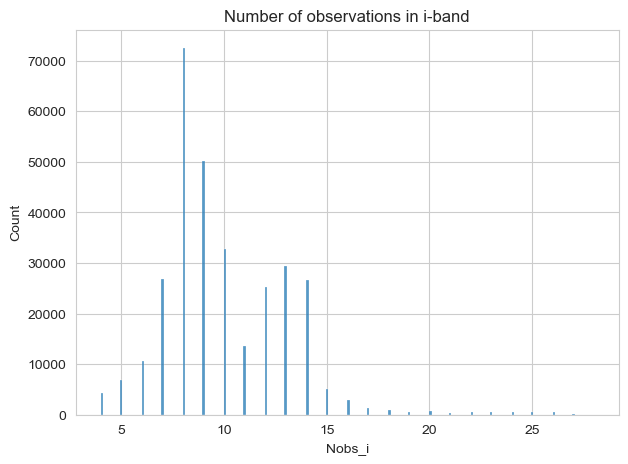

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
sns.histplot(data, x="Nobs_i", ax=ax)
ax.set_title("Number of observations in i-band")


In [21]:
data.columns

Index(['RA', 'DEC', 'RArms', 'DECrms', 'Ntot', 'A_r', 'Nobs_u', 'mmed_u',
       'mmu_u', 'msig_u', 'mrms_u', 'mchi2_u', 'Nobs_g', 'mmed_g', 'mmu_g',
       'msig_g', 'mrms_g', 'mchi2_g', 'Nobs_r', 'mmed_r', 'mmu_r', 'msig_r',
       'mrms_r', 'mchi2_r', 'Nobs_i', 'mmed_i', 'mmu_i', 'msig_i', 'mrms_i',
       'mchi2_i', 'Nobs_z', 'mmed_z', 'mmu_z', 'msig_z', 'mrms_z', 'mchi2_z',
       'ra2MASS', 'dec2MASS', 'J', 'Jerr', 'H', 'Herr', 'K', 'Kerr', 'theta'],
      dtype='object')

<Axes: >

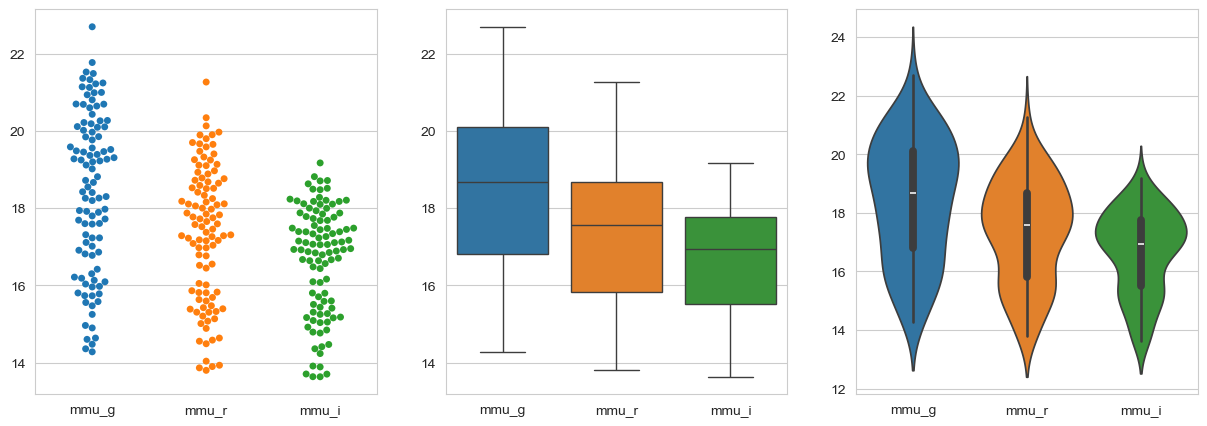

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.swarmplot(data[["mmu_g", "mmu_r", "mmu_i"]].loc[:100], ax=ax1)

sns.boxplot(data[["mmu_g", "mmu_r", "mmu_i"]].loc[:100], ax=ax2)

sns.violinplot(data[["mmu_g", "mmu_r", "mmu_i"]].loc[:100], ax=ax3)

In [32]:
data[["mmu_u", "mmu_g"]].loc[:100]

,mmu_u,mmu_g
0,-0.193000,21.367001
1,20.504999,18.302000
2,18.999001,17.801001
3,18.488001,16.302000
4,19.730000,17.016001
...,...,...
96,22.105000,20.020000
97,22.150999,20.264999
98,22.438999,20.221001
99,20.528000,18.426001


In [45]:

u_g = data['mmu_u'] - data['mmu_g']
g_r = data['mmu_g'] - data['mmu_r']
r_i = data['mmu_r'] - data['mmu_i']
i_z = data['mmu_i'] - data['mmu_z']

data["u_g"] = u_g
data["g_r"] = g_r
data["r_i"] = r_i
data["i_z"] = i_z

<Axes: xlabel='g_r', ylabel='r_i'>

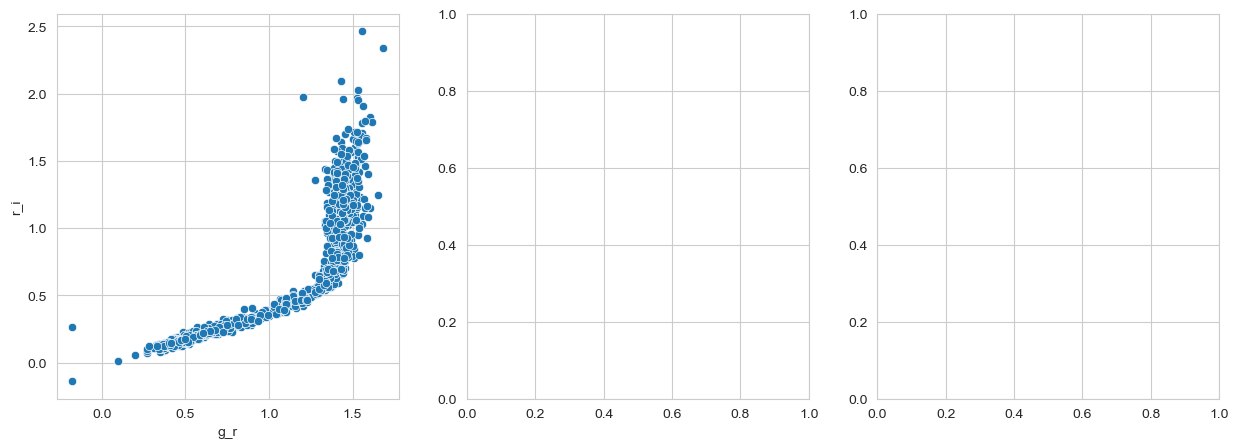

In [55]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(data[["g_r", "r_i"]].loc[:1000],x ="g_r", y="r_i", ax=ax1)


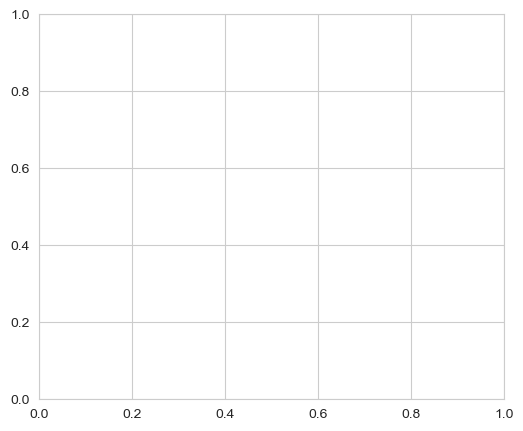

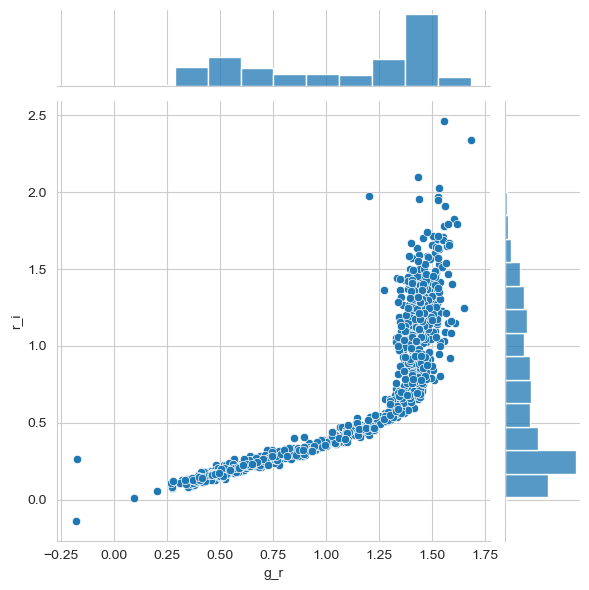

In [54]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,5))

sns.jointplot(data=data[["g_r", "r_i"]].loc[:1000], x="g_r", y="r_i")

